# DS, Mini Project : ESS 배터리 수명 예측 (DAY1)

박준형(U015)

Batch 1·2·3의 수명 분포, 방전 용량, ΔQ(V), 충전 조건, 초기 신호를 비교했습니다. 실제 추출·피처 계산 코드는 `src/day1_eda.py`, 비교 코드는 `src/day1_compare.py`에 있다. 이 노트북은 **실행 결과를 확인하는 읽기용 노트북**이며, 그래프 해석과 결정 근거는 `DAY1-REPORT.md`에 기록했다. 원본 `.mat` 파일은 `data/`에 둔다.

## 재생성

아래 셀을 실행하면 각 배치가 별도 프로세스에서 처리된다. RAM 16GB 환경에서도 배치 사이에 메모리를 비울 수 있도록 했다. 시간이 걸리므로 이미 `results/`가 있으면 건너뛰어도 된다.

In [1]:
from pathlib import Path
import subprocess, sys
ROOT = Path.cwd()
if not (ROOT / 'results/batch_summary.csv').exists():
    for batch in ('batch1','batch2','batch3'):
        subprocess.run([sys.executable, 'src/day1_eda.py', batch], check=True, cwd=ROOT)
    subprocess.run([sys.executable, 'src/day1_compare.py'], check=True, cwd=ROOT)
else:
    print('검증된 results/ 파일을 사용합니다. 원본부터 다시 분석하려면 results/batch_summary.csv를 제거하고 실행하세요.')

검증된 results/ 파일을 사용합니다. 원본부터 다시 분석하려면 results/batch_summary.csv를 제거하고 실행하세요.


## 1. 수명 분포와 짧은 수명 셀

배치별 분포와 500사이클 미만·1,000사이클 초과 비율을 비교합니다. 가장 짧은 셀의 충전 정책과 초기 신호도 확인합니다. 수명 레이블이 없는 셀은 비율의 분모에서 제외합니다.

,batch,cells,labeled,mean_life,median_life,min_life,q25_life,q75_life,max_life,pct_short,pct_long,dq_available,knee_available,median_knee
0,batch1,46,46,844.717391,858.5,534.0,703.25,914.25,1227.0,0.000000,21.739130,46,46,602.0
1,batch2,42,34,550.705882,468.5,392.0,438.25,497.50,1186.0,76.470588,8.823529,42,40,351.0
2,batch3,40,40,1032.000000,964.5,541.0,827.25,1122.75,1935.0,0.000000,47.500000,40,40,766.0


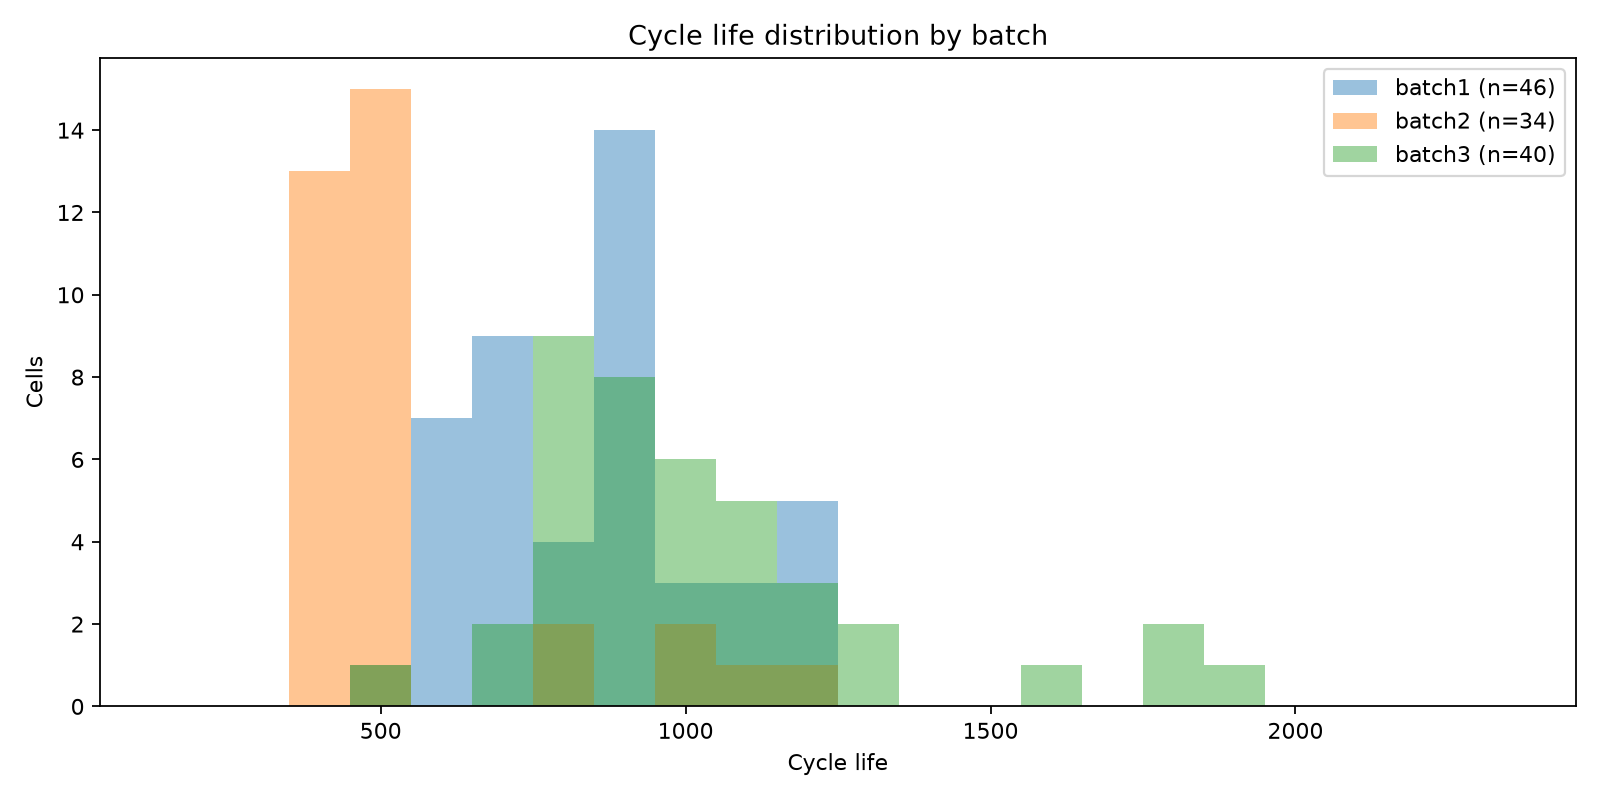

,batch,cell_id,cycle_life,policy,delta_q_logvar
60,batch2,batch2_019,392.0,6C(60%)-3C,-3.292
52,batch2,batch2_006,393.0,3.6C(9%)-5C,-3.530
62,batch2,batch2_021,408.0,6C(60%)-3C,-3.327
71,batch2,batch2_030,412.0,5.6C(26%)-4.5C,-3.185
51,batch2,batch2_005,416.0,3.6C(30%)-6C,-3.086
48,batch2,batch2_002,424.0,5.2C(50%)-4.25C,-3.460
72,batch2,batch2_031,425.0,5.6C(26%)-4.5C,-3.352
57,batch2,batch2_014,426.0,3.6C(30%)-6C,-3.119


In [2]:
import pandas as pd
from IPython.display import display, Image
summary = pd.read_csv('results/batch_summary.csv')
display(summary)
display(Image(filename='results/figures/compare_life.png'))
cells = pd.read_csv('results/paper_screened_cells.csv')
display(cells.nsmallest(8, 'cycle_life')[['batch','cell_id','cycle_life','policy','delta_q_logvar']].round(3))

## 2. 방전 용량 곡선과 탐색적 knee

세 배치의 QD 곡선을 함께 비교합니다. 두 직선으로 근사한 knee는 후반 열화를 설명하는 데만 사용하며 예측 피처에 넣지 않습니다.

,batch,valid,accelerates,median_knee
0,batch1,46,1.000000,602.0
1,batch2,40,0.952381,351.0
2,batch3,40,1.000000,766.0


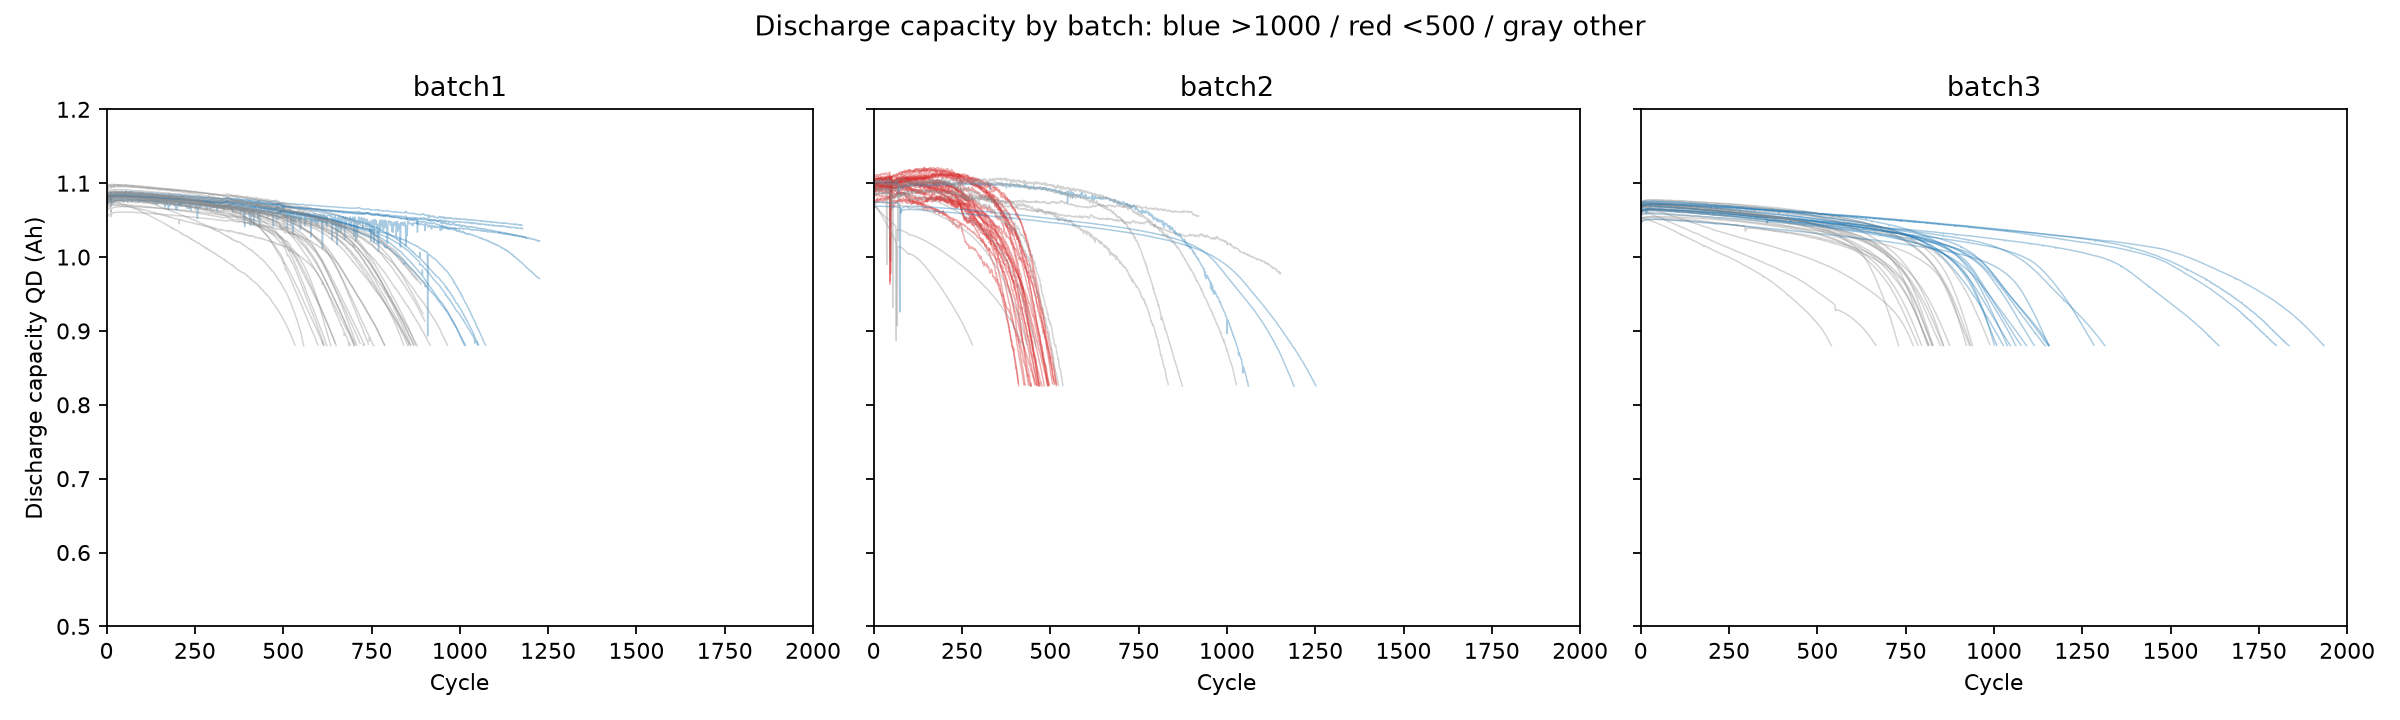

In [3]:
display(pd.read_csv('results/knee_summary.csv'))
display(Image(filename='results/figures/compare_qd.png'))

## 3. 초기 ΔQ(V)와 파생변수

`Qdlin`의 100번째와 10번째 사이클 차이를 계산했다. 핵심 후보는 `log10 var(ΔQ(V))`이다. Batch 1에서만 강한 변수가 아니라 세 배치에서 관계 방향이 유지되는지 확인한다.

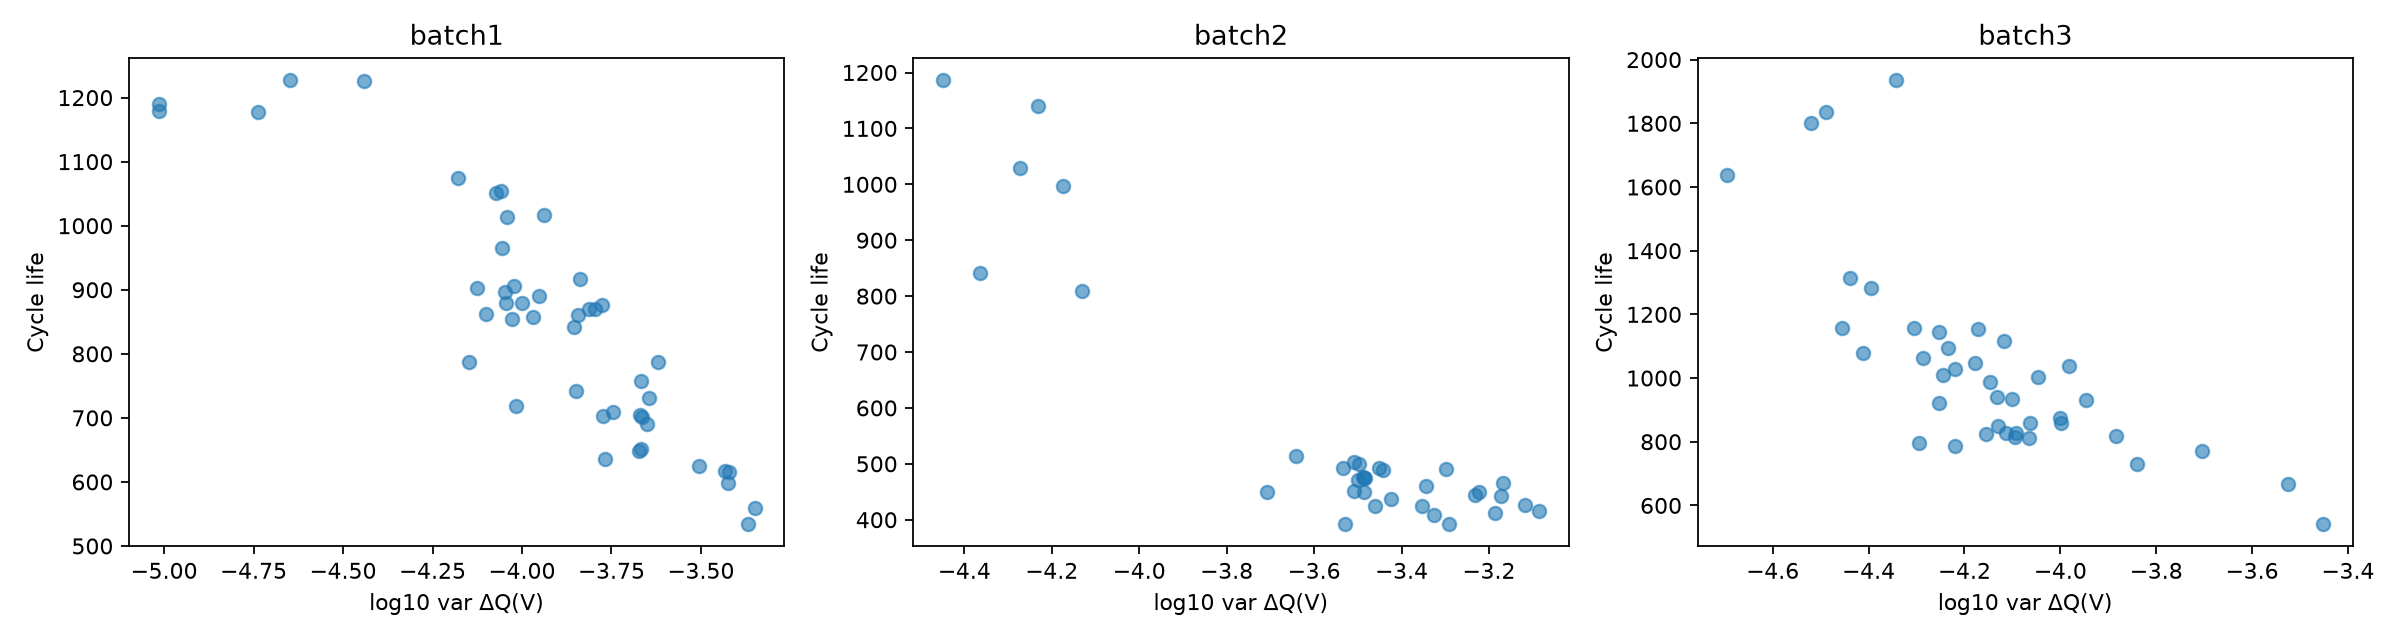

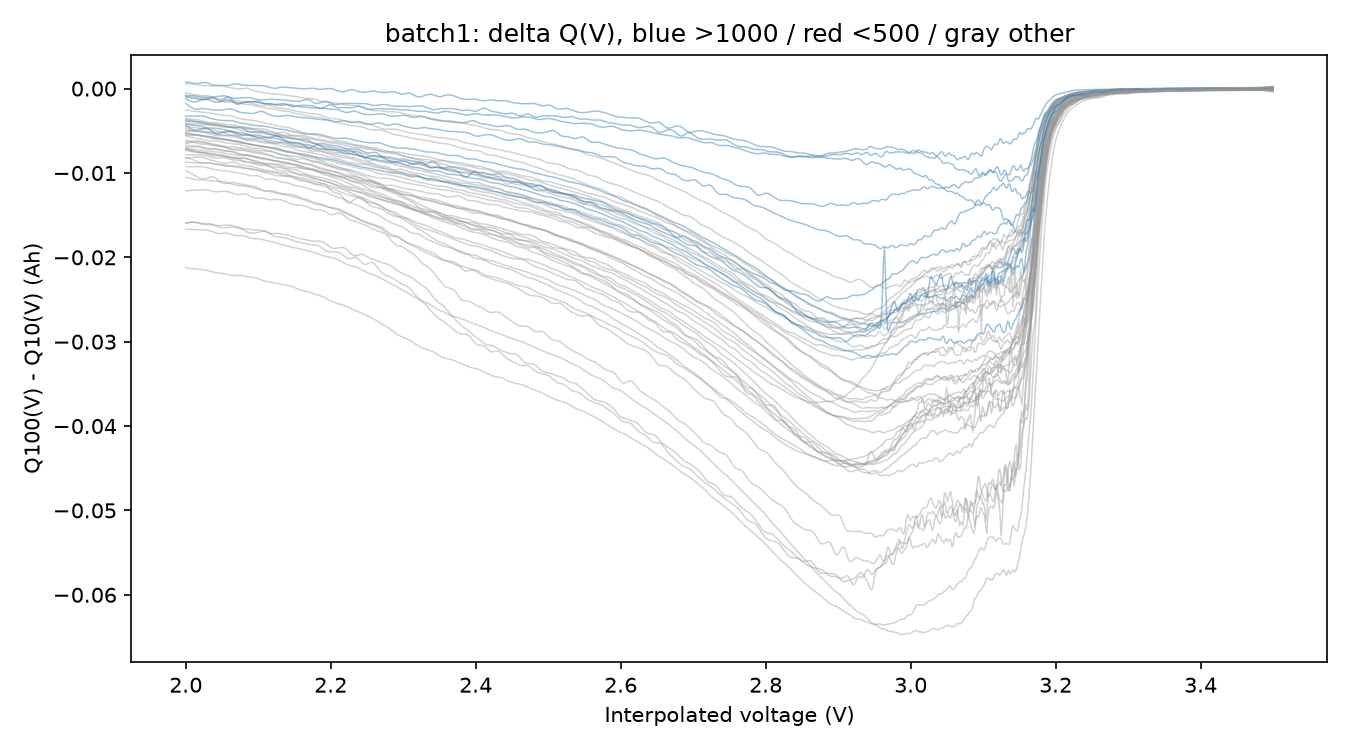

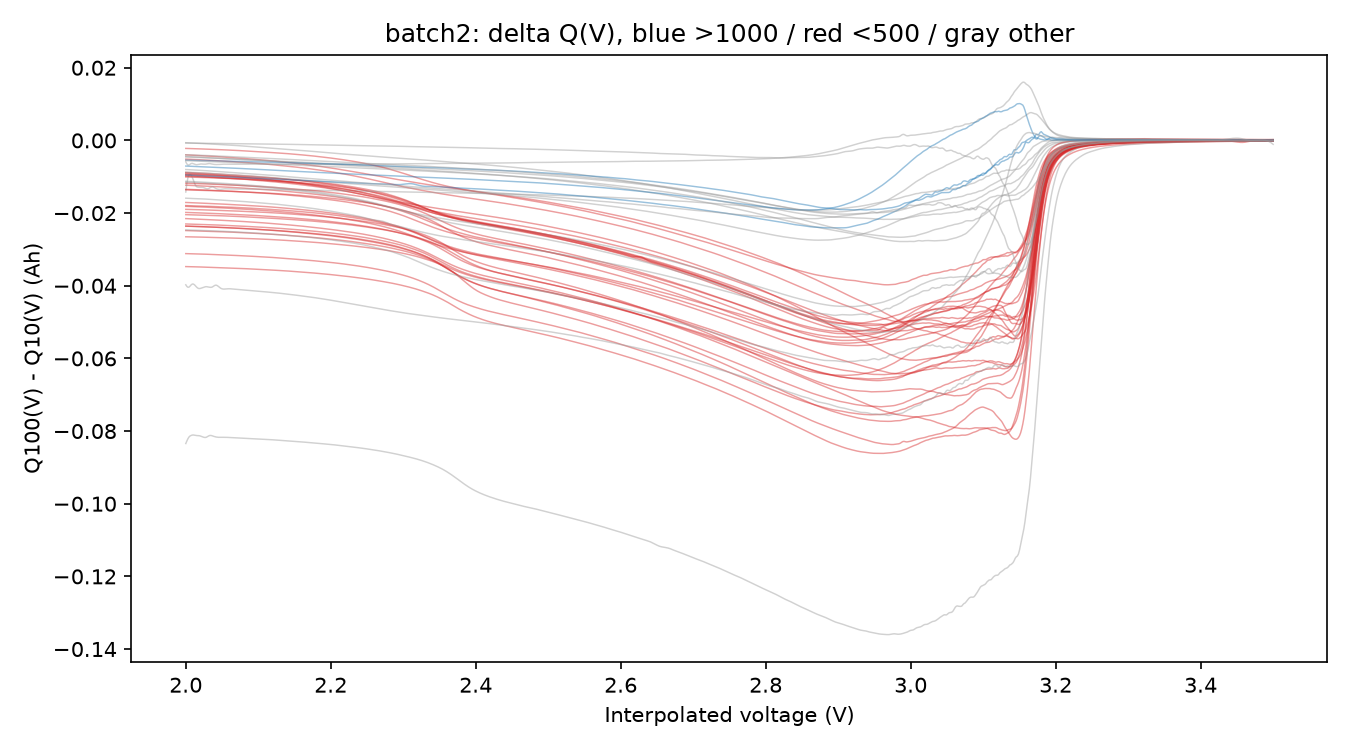

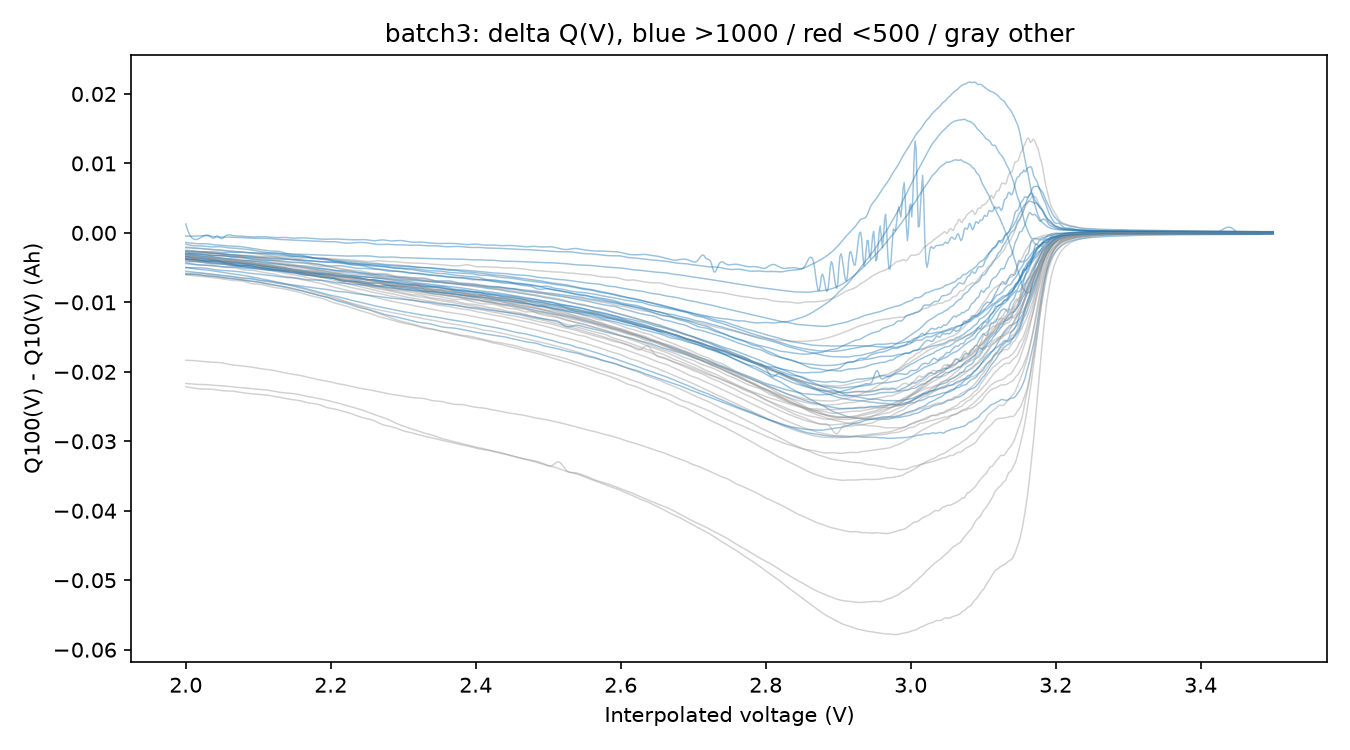

In [4]:
display(Image(filename='results/figures/compare_delta_q.png'))
for batch in ('batch1','batch2','batch3'):
    display(Image(filename=f'results/figures/{batch}_delta_q.png'))

## 4. 충전 정책과 열화 속도

첫 구간 C-rate와 충전 시간뿐 아니라, 0~80% SOC 구간의 C-rate를 구간 길이로 가중한 정책 강도를 비교합니다. 실제 평균 전류를 뜻하는 값은 아닙니다.

,batch,policy,n,mean_life,sd_life,first_c_rate
10,batch1,5.4C(80%)-5.4C,2,546.500000,17.677670,5.40
22,batch1,8C(35%)-3.6C,2,607.500000,12.020815,8.00
18,batch1,7C(40%)-3.6C,2,621.000000,5.656854,7.00
19,batch1,7C(40%)-3C,2,676.000000,39.597980,7.00
21,batch1,8C(25%)-3.6C,2,676.500000,36.062446,8.00
17,batch1,7C(30%)-3.6C,2,722.500000,27.577164,7.00
9,batch1,5.4C(70%)-3C,2,739.500000,68.589358,5.40
16,batch1,6C(60%)-3C,2,744.000000,18.384776,6.00
2,batch1,4.8C(80%)-4.8C,2,753.000000,165.462987,4.80
14,batch1,6C(50%)-3.6C,2,792.500000,118.086832,6.00


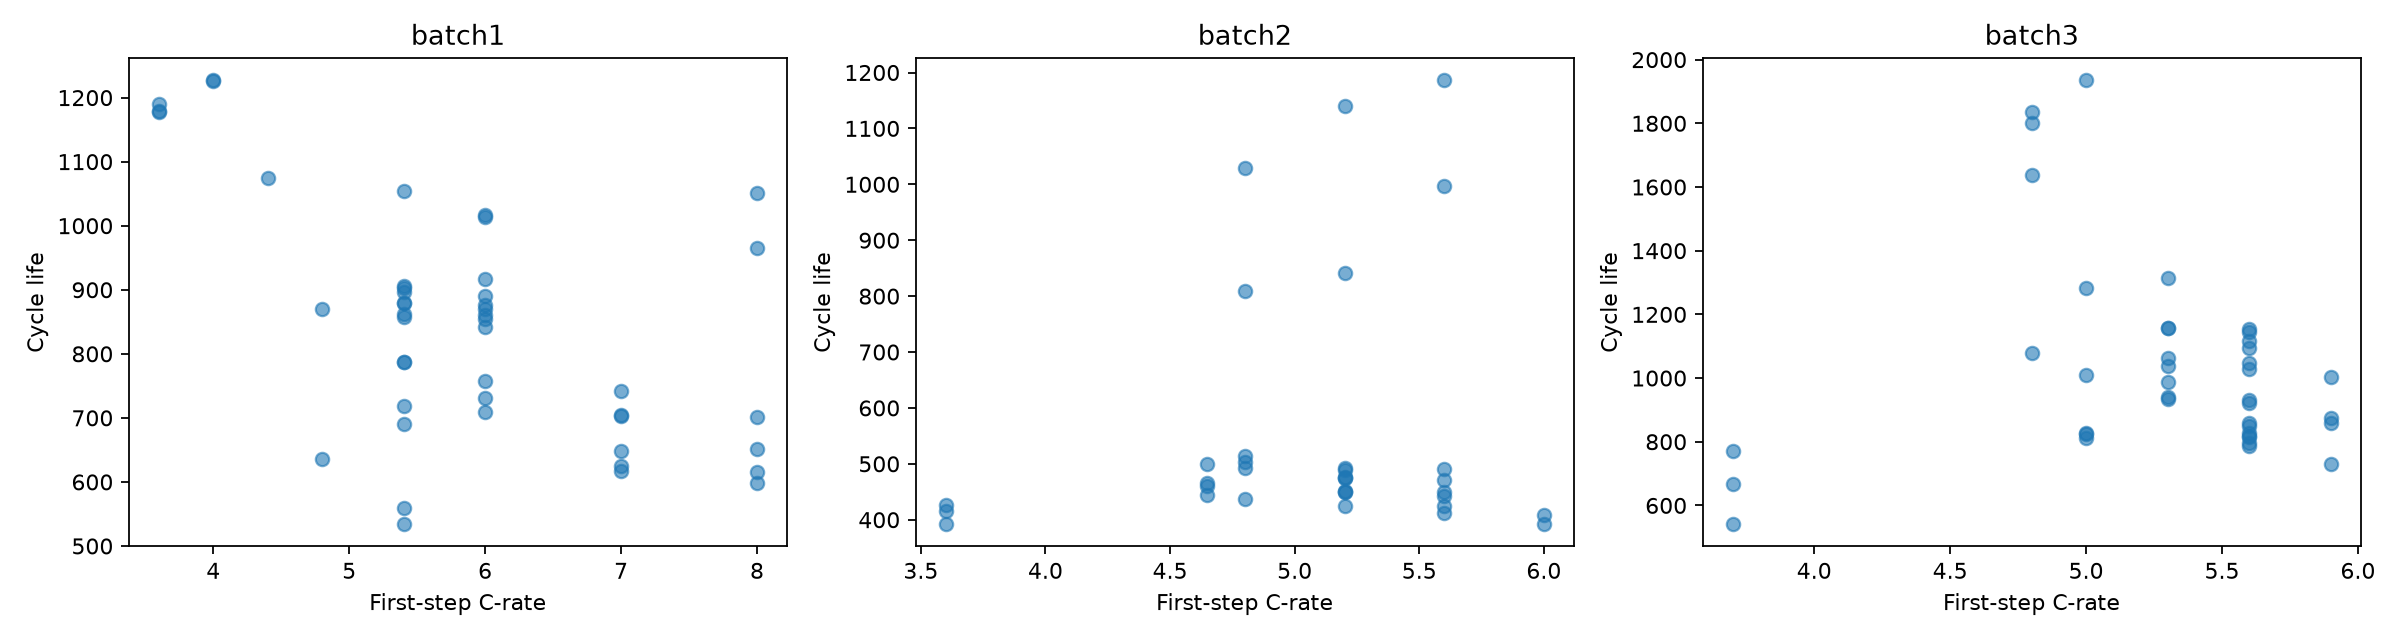

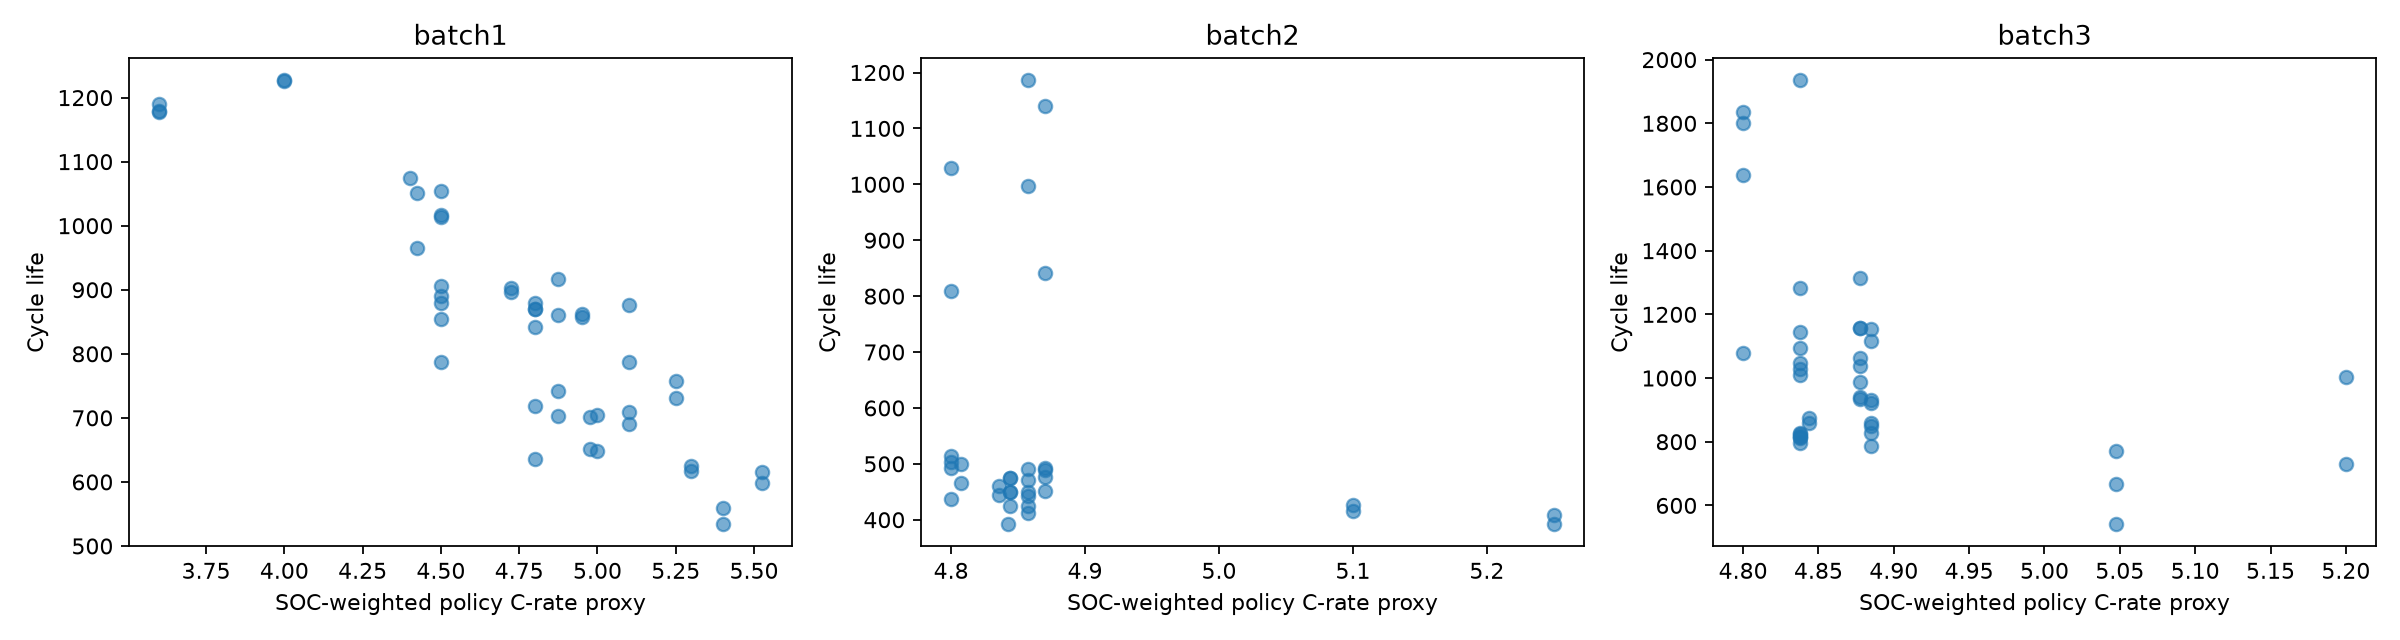

In [5]:
policy = pd.read_csv('results/policy_summary.csv')
display(policy.sort_values(['batch','mean_life']))
display(Image(filename='results/figures/compare_c_rate.png'))
display(Image(filename='results/figures/compare_policy_rate.png'))

## 5. 초기 신호의 상관관계와 변수 중복

초기 신호와 수명의 상관을 배치별로 비교합니다. Batch 1에서는 정책 강도와 ΔQ(V)의 상관도 높아 두 변수의 독립적인 기여를 단정하지 않습니다.

batch,batch1,batch2,batch3
feature,,,
delta_q_logvar,-0.871,-0.709,-0.759
delta_q_mean_abs,-0.828,-0.680,-0.719
early_mean_IR,0.189,-0.112,0.213
early_mean_QD,0.185,0.153,0.247
early_mean_Tavg,-0.371,0.134,0.017
early_mean_Tmax,-0.323,-0.138,-0.072
early_mean_chargetime,0.613,-0.319,0.049
first_c_rate,-0.483,-0.055,-0.163
policy_rate_proxy,-0.869,-0.267,-0.428


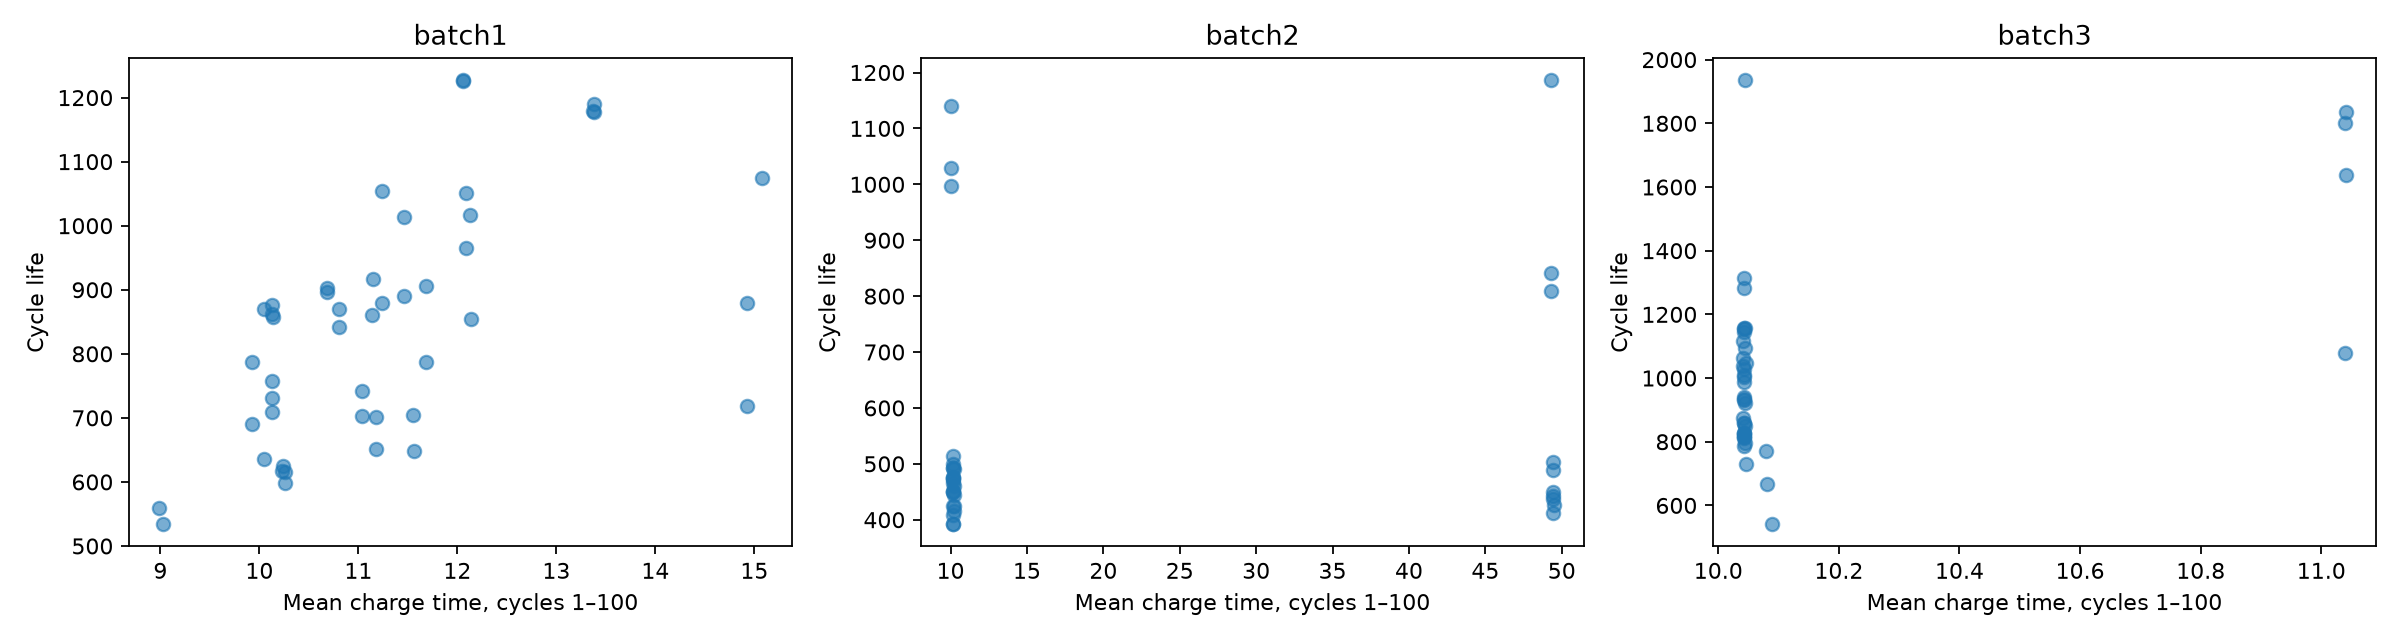

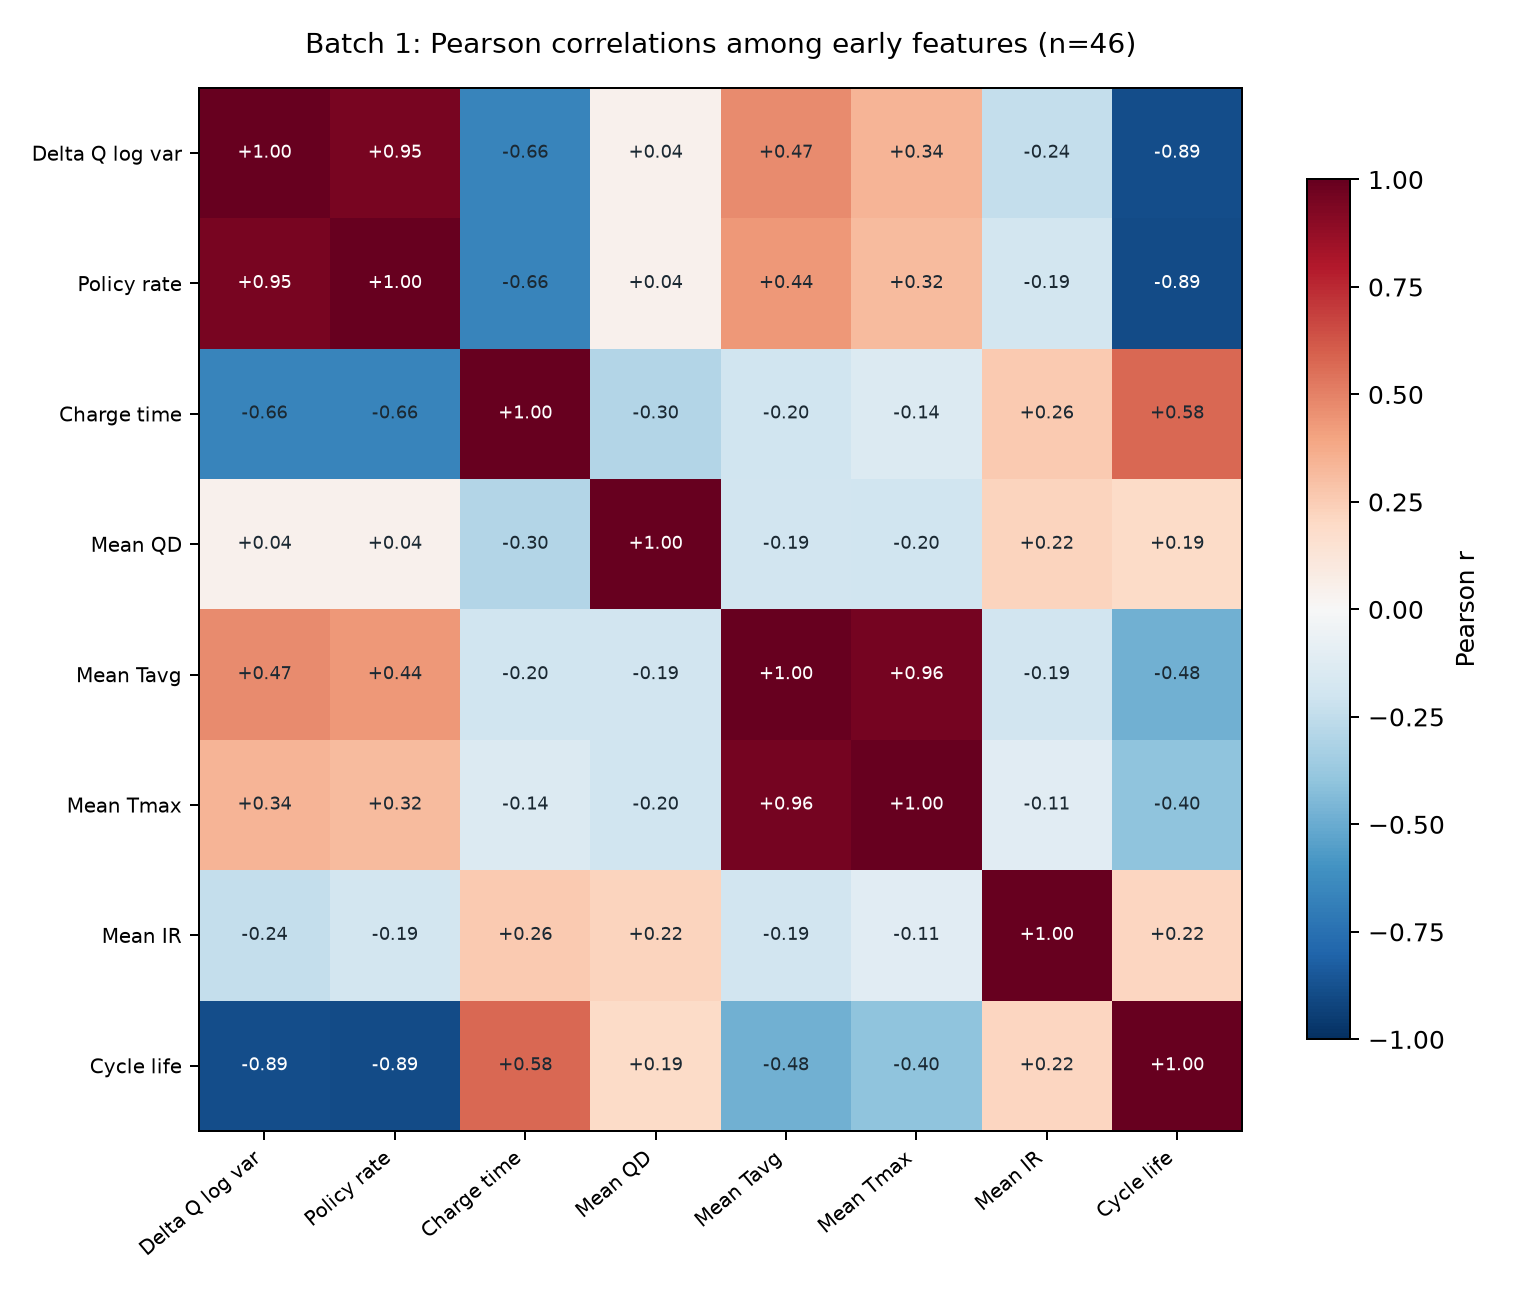

,batch,cell_id,cycle_life,policy,first_c_rate,n_cycles,n_early,early_mean_QD,early_mean_QC,early_mean_IR,...,delta_q_logvar,delta_q_mean_abs,delta_q_min,knee_cycle,slope_before,slope_after,policy_switch_soc,second_c_rate,policy_rate_proxy,reference_exclusion
0,batch1,batch1_000,1190.0,3.6C(80%)-3.6C,3.6,1189,100,1.080597,1.080434,0.016643,...,-5.014861,0.002955,-0.008460,513.0,-0.000033,-0.000042,80.0,3.6,3.6,False
1,batch1,batch1_001,1179.0,3.6C(80%)-3.6C,3.6,1178,100,1.081247,1.081092,0.016922,...,-5.013960,0.004100,-0.011004,412.0,-0.000023,-0.000044,80.0,3.6,3.6,False
2,batch1,batch1_002,1177.0,3.6C(80%)-3.6C,3.6,1176,100,1.085371,1.085146,0.016769,...,-4.737000,0.004487,-0.017216,432.0,-0.000022,-0.000044,80.0,3.6,3.6,False
3,batch1,batch1_003,1226.0,4C(80%)-4C,4.0,1225,100,1.084949,1.084546,0.016311,...,-4.442613,0.007468,-0.018961,962.0,-0.000045,-0.000252,80.0,4.0,4.0,False
4,batch1,batch1_004,1227.0,4C(80%)-4C,4.0,1226,100,1.082844,1.082700,0.016669,...,-4.647744,0.005751,-0.013958,892.0,-0.000039,-0.000086,80.0,4.0,4.0,False


In [6]:
corr = pd.read_csv('results/feature_correlations.csv')
display(corr.pivot(index='feature', columns='batch', values='spearman').round(3))
display(Image(filename='results/figures/compare_charge_time.png'))
display(Image(filename='results/figures/batch1_feature_heatmap.png'))
display(pd.read_csv('results/paper_screened_cells.csv').head())

## 6. 후보 모델 선정과 Batch 1 사전 비교

중앙값 예측을 기준선으로 두고, 변수 중복과 적은 셀 수를 고려해 Ridge·Elastic Net을 비교합니다. 얕은 트리는 비선형 관계를 확인하는 후보입니다. 충전 정책별 5분할 검증 결과를 보고 세 변수 Ridge를 시작 모델로 선택했습니다. Batch 2 점수는 계산하지 않았습니다.

,experiment,mean_mape_pct,sd_mape_pct,mean_mae_cycles,pooled_mape_pct,pooled_mae_cycles
0,ridge_compact_with_policy,7.75,1.80,67.80,7.75,67.83
1,ridge_compact,8.18,1.72,72.25,8.21,72.48
2,elasticnet_compact,8.32,1.47,72.78,8.34,72.98
3,ridge_delta_only,9.35,0.82,80.15,9.38,80.46
4,ridge_policy_proxy_only,9.49,1.53,78.15,9.47,78.13
5,tree_compact,10.62,2.28,84.59,10.77,85.72
6,ridge_basic,14.56,5.76,119.12,14.62,119.78
7,median_baseline,18.91,5.47,149.23,18.88,149.61


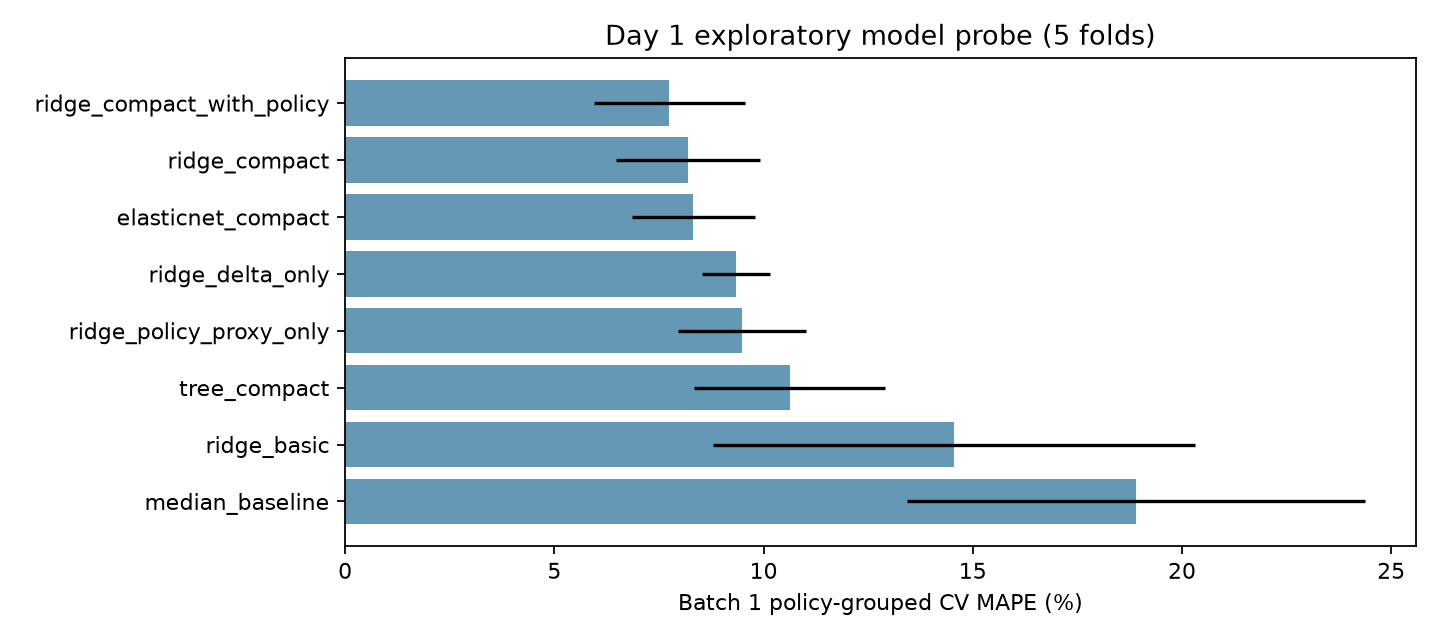

,experiment,cell_id,policy,fold,actual,predicted,abs_error
185,ridge_compact,batch1_001,3.6C(80%)-3.6C,1,1179.0,1427.3,248.3
184,ridge_compact,batch1_000,3.6C(80%)-3.6C,1,1190.0,1420.9,230.9
208,ridge_compact,batch1_024,6C(40%)-3C,2,1017.0,822.4,194.6
187,ridge_compact,batch1_003,4C(80%)-4C,2,1226.0,1053.1,172.9
225,ridge_compact,batch1_041,8C(15%)-3.6C,4,1051.0,895.3,155.7
190,ridge_compact,batch1_006,4.8C(80%)-4.8C,3,636.0,787.8,151.8
189,ridge_compact,batch1_005,4.4C(80%)-4.4C,4,1074.0,931.8,142.2
186,ridge_compact,batch1_002,3.6C(80%)-3.6C,1,1177.0,1308.7,131.7


In [7]:
from pathlib import Path
import subprocess, sys
if not Path('results/day1_probe_summary.csv').exists():
    subprocess.run([sys.executable,'src/day1_model_probe.py'],check=True)
probe = pd.read_csv('results/day1_probe_summary.csv')
display(probe.round(2))
display(Image(filename='results/figures/day1_probe.png'))
pred = pd.read_csv('results/day1_probe_predictions.csv')
ridge = pred[pred.experiment == 'ridge_compact']
display(ridge.sort_values('abs_error',ascending=False).head(8).round(1))